# Wildfire susceptibility: a Random Forest baseline

This notebook is a compact end-to-end example for environmental modelling.
It separates the main steps of the ML pipeline:

1. notebook init
2. data preprocessing and feature engineering
3. feature engineering for aspect and vegetation
4. training dataset preparation with pseudo-absences
5. model tuning
6. training
7. testing
8. metrics
9. model explanation

The row unit is one valid 100 m pixel.
The target is `1` for pixels burned in the period being sampled and `0` for
sampled pixels unburned in that period.
The output is a relative susceptibility score, not a calibrated annual fire probability.

## 1. Notebook init

This cell loads the lesson setup script. In Colab, it first downloads the
script from GitHub; the script then installs dependencies and clones the
repository data into the runtime.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

setup_path = Path("lesson_setup.py")
if not setup_path.exists():
    urlretrieve(
        "https://raw.githubusercontent.com/mirkodandrea/wildfire-susceptibility-ml-lesson/main/lesson_setup.py",
        setup_path,
    )

from lesson_setup import *  # noqa: F403

RANDOM_STATE = 42
HOLDOUT_START_YEAR = 2016

DATA_DIR = Path("data")
FIRE_RASTER_DIR = DATA_DIR / "fires"

RASTER_PATHS = {
    "elevation": DATA_DIR / "elevation.tif",
    "slope": DATA_DIR / "slope.tif",
    "aspect": DATA_DIR / "aspect.tif",
    "vegetation": DATA_DIR / "vegetation.tif",
    "urban_distance": DATA_DIR / "urban_distance.tif",
    "roads_distance": DATA_DIR / "roads_distance.tif",
}

RASTER_NUMERIC_FEATURES = ["elevation", "slope", "aspect", "urban_distance", "roads_distance"]
NUMERIC_FEATURES = ["elevation", "slope", "aspect_eastness", "aspect_northness", "urban_distance", "roads_distance"]
RASTER_FEATURES = [*RASTER_NUMERIC_FEATURES, "vegetation"]
FEATURES = [*NUMERIC_FEATURES, "vegetation"]

VEGETATION_NAMES = {
    # Mixed broadleaf forests
    3112: "Warm-climate mixed forest",
    3113: "Moist-climate mixed forest",
    313: "Mixed forest",

    # Dominant tree-species forests
    3114: "Beech forest",
    3115: "Chestnut forest",
    3116: "Chestnut orchard",

    # Evergreen and conifer forests
    3111: "Evergreen dry forest",
    312: "Coniferous forest",

    # Water-associated vegetation
    3117: "Riparian vegetation",

    # Shrub and transitional vegetation
    322: "Shrubland and scrub",
    323: "Mediterranean evergreen scrub",
    324: "Woodland-shrub transition",
}

VEGETATION_CODES = list(VEGETATION_NAMES)
VEGETATION_COLORS = {
    3112: "#5aae61",
    3113: "#1b7837",
    313: "#00441b",
    3114: "#74c476",
    3115: "#238b45",
    3116: "#8c6d31",
    3111: "#2b8c4b",
    312: "#006d2c",
    3117: "#2b8cbe",
    322: "#d8b365",
    323: "#b35806",
    324: "#a6d96a",
}
VEGETATION_CMAP = ListedColormap([VEGETATION_COLORS[code] for code in VEGETATION_CODES])
VEGETATION_NORM = BoundaryNorm(
    np.arange(-0.5, len(VEGETATION_CODES) + 0.5),
    VEGETATION_CMAP.N,
)

## Prediction problem

A wildfire susceptibility baseline asks whether pixels that burn in future
years have distinguishable environmental signatures. We train on pre-2016
burned and unburned pixels, then evaluate on a 2016-2022 hold-out period.
The model output is a ranking score: higher means "more similar to pixels that
burned in the training period".

- **Unit:** one valid 100 m pixel
- **Positive label:** pixel centre in a burned raster cell for the evaluated period
- **Negative label:** sampled unburned pixel for training; every valid unburned
  pixel for hold-out evaluation
- **Model output:** relative susceptibility score
- **Main caveat:** nearby pixels are not independent and predictors are static

## 2. Data preprocessing and feature engineering

Raster values become feature columns in the modelling table.
We assume all predictors are on the same grid.

### Choose the reference grid

Raster data are stored as regular grids. The `slope` raster is used as the
reference grid for the rest of the workflow:

- `TEMPLATE_SHAPE` tells us how many rows and columns the analysis grid has
- `TEMPLATE_TRANSFORM` converts between raster row/column indices and map
  coordinates

The yearly burned-area rasters use this same grid, so target labels and
predictor values refer to the same pixel locations.

In [2]:
with rasterio.open(RASTER_PATHS["slope"]) as src:
    TEMPLATE_TRANSFORM = src.transform
    TEMPLATE_SHAPE = (src.height, src.width)

extent = (
    TEMPLATE_TRANSFORM.c,
    TEMPLATE_TRANSFORM.c + TEMPLATE_TRANSFORM.a * TEMPLATE_SHAPE[1],
    TEMPLATE_TRANSFORM.f + TEMPLATE_TRANSFORM.e * TEMPLATE_SHAPE[0],
    TEMPLATE_TRANSFORM.f,
)

raster_arrays = {}

for name, path in RASTER_PATHS.items():
    with rasterio.open(path) as src:
        raster_arrays[name] = src.read(1, masked=True).astype("float32").filled(np.nan)

### Create the analysis mask

The model should only learn from pixels where the predictors are meaningful.
The vegetation raster defines the broad analysis domain: pixels with missing
vegetation or code `0` are excluded. Source numeric predictors are then masked
to this same domain, and `valid_mask` keeps only pixels where every source
numeric predictor is available.

This mask is reused throughout the notebook. It limits sampling, evaluation,
and final mapping to the same set of valid landscape pixels.

In [3]:
vegetation = raster_arrays["vegetation"]
analysis_mask = np.isfinite(vegetation) & (vegetation != 0)

valid_mask = analysis_mask.copy()
for feature in RASTER_NUMERIC_FEATURES:
    raster_arrays[feature] = np.where(analysis_mask, raster_arrays[feature], np.nan)
    valid_mask &= np.isfinite(raster_arrays[feature])

valid_pixel_count = int(valid_mask.sum())
display(Markdown("### Valid analysis pixels"))
display(valid_pixel_count)

### Valid analysis pixels

398697

In [4]:
raster_summary_df = pd.DataFrame(
    [
        {
            "feature": feature,
            "valid_pixels": int(np.isfinite(raster_arrays[feature]).sum()),
            "median": float(np.nanmedian(raster_arrays[feature])),
        }
        for feature in RASTER_NUMERIC_FEATURES
    ]
)
display(Markdown("### Raster predictor summary"))
display(raster_summary_df)

### Raster predictor summary

,feature,valid_pixels,median
0,elevation,404235,554.000000
1,slope,398699,19.125053
2,aspect,398697,177.131866
3,urban_distance,404245,583.095154
4,roads_distance,404245,300.000000


### Map all predictor rasters

Mapping each feature is a quick visual check before modelling. It helps reveal
spatial structure, missing areas, and variables that may be strongly tied to
geography. The vegetation layer is categorical; the other source predictors
are continuous rasters.

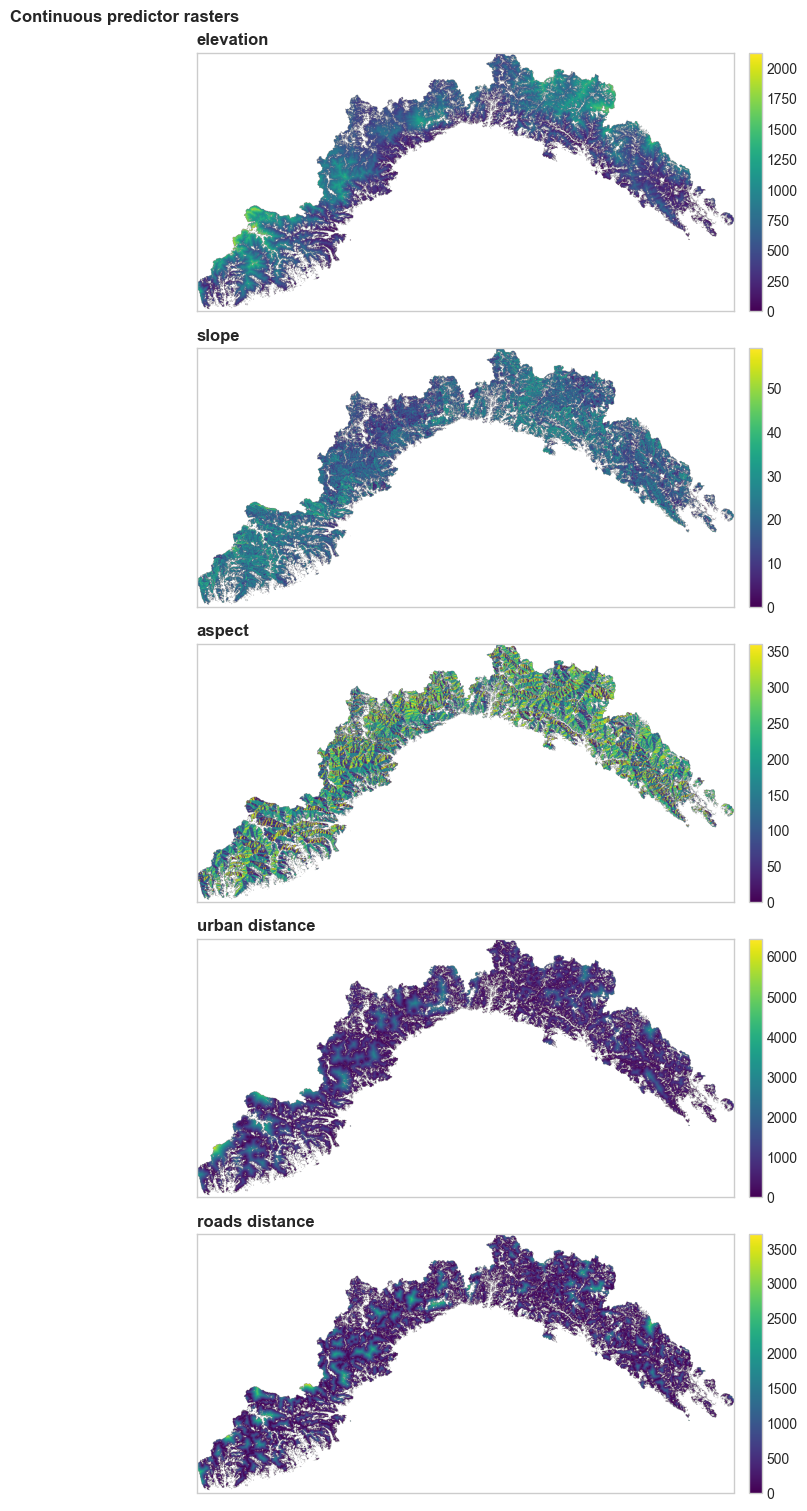

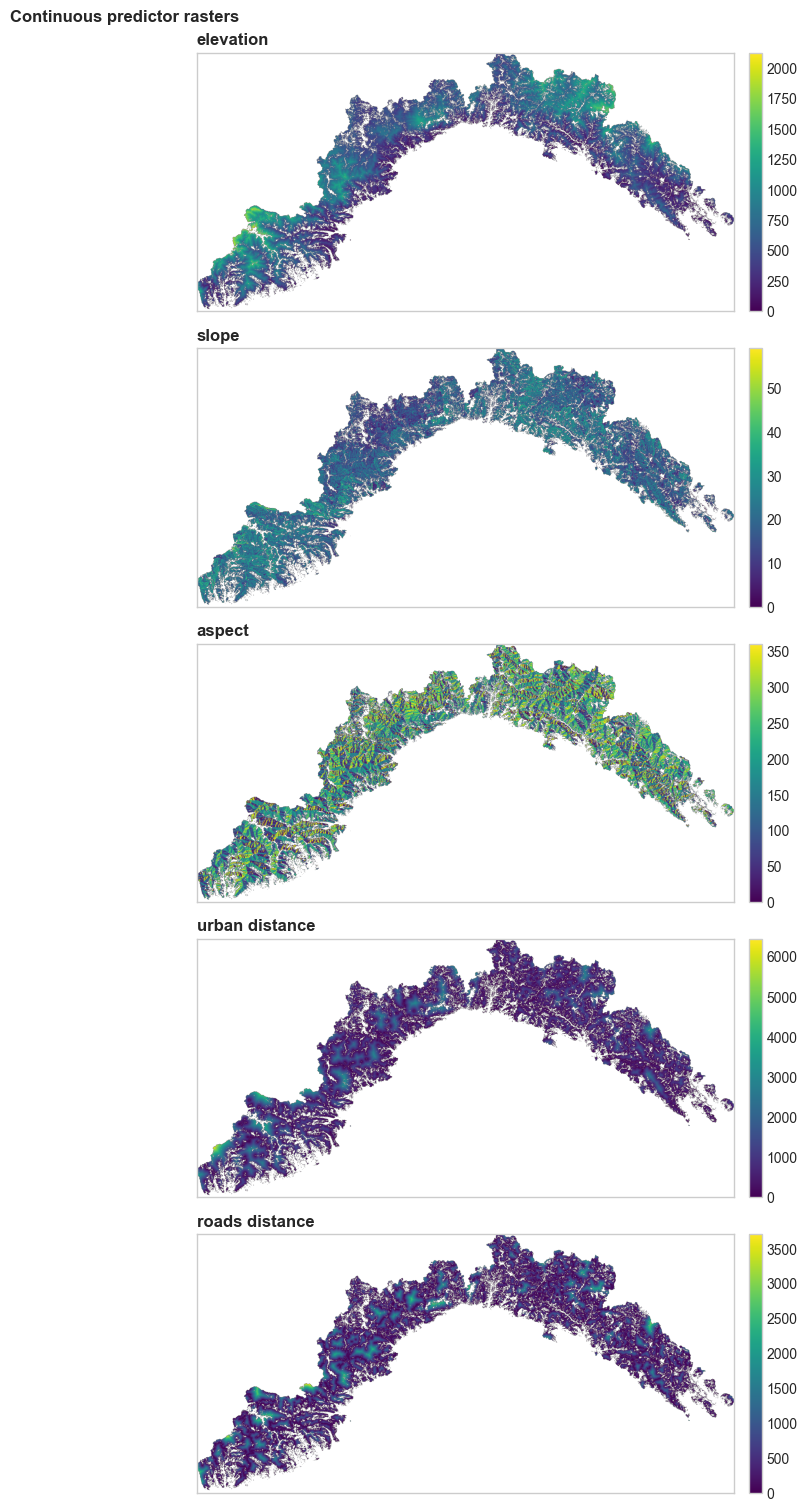

In [5]:
fig, axes = plt.subplots(
    len(RASTER_NUMERIC_FEATURES),
    1,
    figsize=(8, 3 * len(RASTER_NUMERIC_FEATURES)),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, feature in zip(axes, RASTER_NUMERIC_FEATURES):
    feature_map = np.where(analysis_mask, raster_arrays[feature], np.nan)
    image = ax.imshow(feature_map, extent=extent, origin="upper", cmap="viridis")
    fig.colorbar(image, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(feature.replace("_", " "), loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Continuous predictor rasters", x=0.01, ha="left", fontweight="bold")
fig

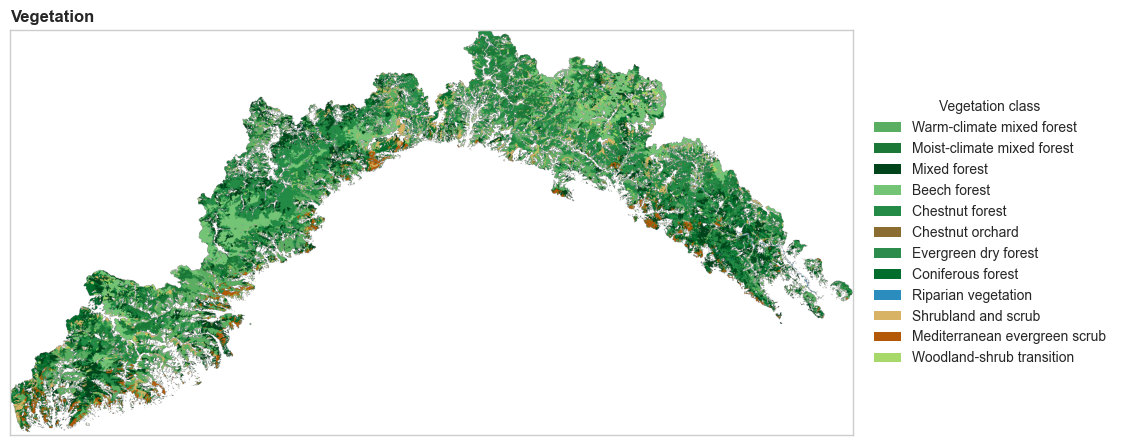

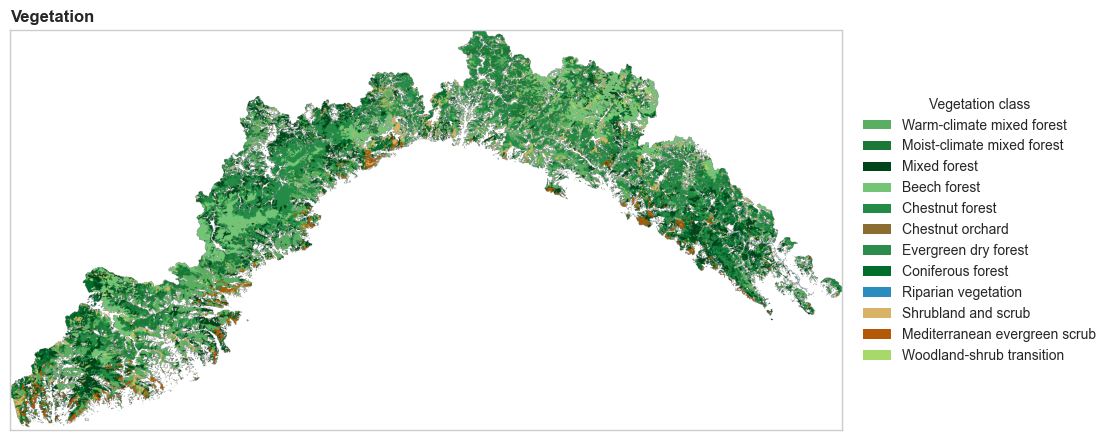

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
feature_map = np.where(analysis_mask, raster_arrays["vegetation"], np.nan)
code_to_index = {code: index for index, code in enumerate(VEGETATION_CODES)}
vegetation_map = np.full(feature_map.shape, np.nan, dtype=float)
for code, index in code_to_index.items():
    vegetation_map[feature_map == code] = index

ax.imshow(
    vegetation_map,
    extent=extent,
    origin="upper",
    cmap=VEGETATION_CMAP,
    norm=VEGETATION_NORM,
)
legend_handles = [
    Patch(facecolor=VEGETATION_COLORS[code], edgecolor="none", label=VEGETATION_NAMES[code])
    for code in VEGETATION_CODES
    if np.any(feature_map == code)
]
ax.legend(
    handles=legend_handles,
    title="Vegetation class",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
)
ax.set_title("Vegetation", loc="left", fontweight="bold")
ax.set_xticks([])
ax.set_yticks([])
fig

### Burned-area rasters

Yearly burned-area rasters define the positive label.
Each file is a binary raster on the predictor grid:

- `1` means the pixel burned in that year
- `0` means the pixel did not burn in that year

We use the years only for validation design:

- training period: years before 2016
- hold-out period: 2016-2022

In [7]:
fire_raster_paths = {
    int(path.stem.split("_")[1]): path
    for path in sorted(FIRE_RASTER_DIR.glob("fire_*.tiff"))
}
fire_years = sorted(fire_raster_paths)

if not fire_years:
    raise FileNotFoundError(f"No fire rasters found in {FIRE_RASTER_DIR}")

fire_masks = {}
for year, path in fire_raster_paths.items():
    with rasterio.open(path) as src:
        fire_masks[year] = src.read(1).astype(bool)

pixel_area_km2 = abs(TEMPLATE_TRANSFORM.a * TEMPLATE_TRANSFORM.e) / 1_000_000
fire_summary_df = pd.DataFrame(
    [
        {
            "fire_year": year,
            "burned_pixels": int(mask.sum()),
            "burned_area_km2": int(mask.sum()) * pixel_area_km2,
        }
        for year, mask in fire_masks.items()
    ]
)
display(Markdown("### Burned-area summary by year"))
display(fire_summary_df)

### Burned-area summary by year

,fire_year,burned_pixels,burned_area_km2
0,1997,8683,86.83
1,1998,4689,46.89
2,1999,6887,68.87
3,2000,3495,34.95
4,2001,5350,53.50
5,2002,2942,29.42
6,2003,7747,77.47
7,2004,1310,13.10
8,2005,3995,39.95
9,2006,1533,15.33


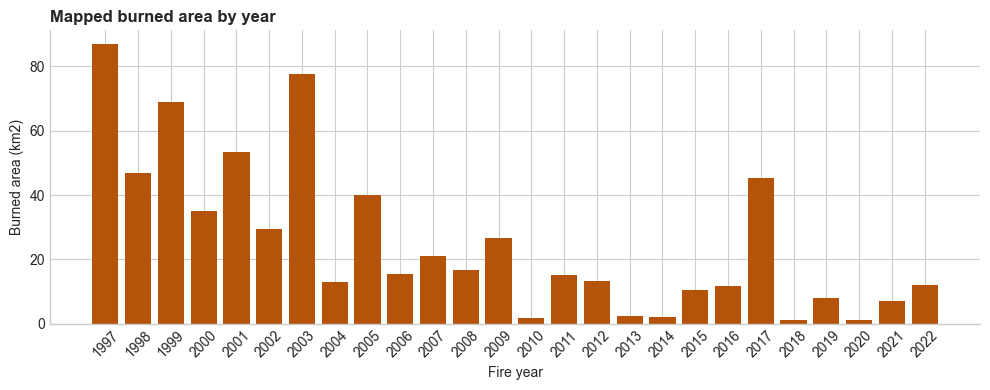

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fire_summary_df["fire_year"].astype(str), fire_summary_df["burned_area_km2"], color="#b45309")
ax.set_title("Mapped burned area by year", loc="left", fontweight="bold")
ax.set_xlabel("Fire year")
ax.set_ylabel("Burned area (km2)")
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

## 3. Feature engineering

Scikit-learn's `RandomForestClassifier` needs numeric columns.
The continuous raster predictors are already numeric, but aspect needs a
circular representation and vegetation is a category code. Aspect values near
0 and 360 degrees represent similar directions, so modelling raw degrees would
create an artificial discontinuity. We convert aspect to eastness and
northness:

- `aspect_eastness = sin(aspect in radians)`
- `aspect_northness = cos(aspect in radians)`

Vegetation code `3111` is not smaller or larger than code `324` in a useful
ecological sense.

One-hot encoding solves that by creating one binary column per vegetation
class. Each row gets a `1` in its own vegetation class and `0` in the others.

The training columns become the reference. Validation, test, and map data are
always reindexed to those same columns so all model inputs have the same shape.

In [9]:
def add_aspect_features(frame):
    """Add eastness and northness from aspect degrees."""
    engineered = frame.copy()
    aspect_radians = np.deg2rad(engineered["aspect"])
    engineered["aspect_eastness"] = np.sin(aspect_radians)
    engineered["aspect_northness"] = np.cos(aspect_radians)
    return engineered


def one_hot_encode_vegetation(frame):
    """Return one binary column per vegetation class."""
    vegetation_codes = frame["vegetation"].astype(int)
    vegetation_dummies = pd.get_dummies(
        vegetation_codes,
        prefix="vegetation",
        dtype=int,
    )
    return vegetation_dummies.reset_index(drop=True)


def make_features(frame, feature_columns=None):
    """Build the numeric model matrix used by the Random Forest."""
    engineered_frame = add_aspect_features(frame) if "aspect" in frame.columns else frame
    numeric_features = engineered_frame[NUMERIC_FEATURES].reset_index(drop=True)
    vegetation_features = one_hot_encode_vegetation(engineered_frame)

    model_features = pd.concat(
        [numeric_features, vegetation_features],
        axis=1,
    )

    if feature_columns is not None:
        model_features = model_features.reindex(
            columns=feature_columns,
            fill_value=0,
        )

    return model_features

## 4. Training dataset preparation with pseudo-absences

The geospatial problem becomes standard supervised learning after sampling:
each row is a pixel, feature columns come from rasters, and the target comes
from the burned-area rasters.

We use a temporal split:

- pre-2016 pixels are the training pool
- a random split of that pool creates a validation set for tuning
- 2016-2022 pixels are the final hold-out test set

The pre-2016 training pool is balanced: keep all valid burned pixels and
sample the same number of valid unburned pixels.

The 2016-2022 hold-out test uses the full valid landscape: every valid pixel is
labelled burned or unburned for the hold-out period. This makes test metrics
reflect the real class imbalance in the evaluation period.

### Convert selected pixels into rows

`pixel_frame` is the bridge between raster data and tabular machine learning.
It receives raster row/column indices, converts them to map coordinates, and
extracts each predictor value at those pixel locations.

The returned table has one row per pixel. Keeping `row`, `col`, `x`, and `y`
makes it possible to move back and forth between model tables and maps.

### Combine yearly fire rasters by period

The yearly fire rasters are already on the predictor grid. For a period such
as 1997-2015 or 2016-2022, we combine the corresponding yearly rasters with a
logical OR. A `True` cell means that pixel burned at least once during that
period.

The training helper keeps all valid burned pixels and randomly samples the
same number of valid unburned pixels. Those unburned samples are
pseudo-absences: they are valid landscape pixels with no mapped fire in the
training period, used as the comparison class for this baseline.

The hold-out helper keeps every valid pixel so the test set reflects the real
imbalance between burned and unburned landscape.

### Build temporal datasets

Fires before 2016 define the training pool. Fires from 2016 onward define the
final hold-out test period. The validation split is carved out of the
pre-2016 training pool, so model selection never sees the later fires.

This keeps two evaluation questions separate:

- validation: which Random Forest settings work best on pre-2016 samples?
- hold-out: do those settings rank later burned pixels higher than later
  unburned pixels?

In [10]:
train_years = [year for year in fire_years if year < HOLDOUT_START_YEAR]
test_years = [year for year in fire_years if year >= HOLDOUT_START_YEAR]

train_burned_mask = combined_fire_mask(fire_masks, train_years)
test_burned_mask = combined_fire_mask(fire_masks, test_years)

### Map the labels used by each period

The training label map marks pixels that burned at least once before 2016.
The hold-out label map marks pixels that burned at least once from 2016 to
2022. These maps show the spatial target pattern before any model is fitted.

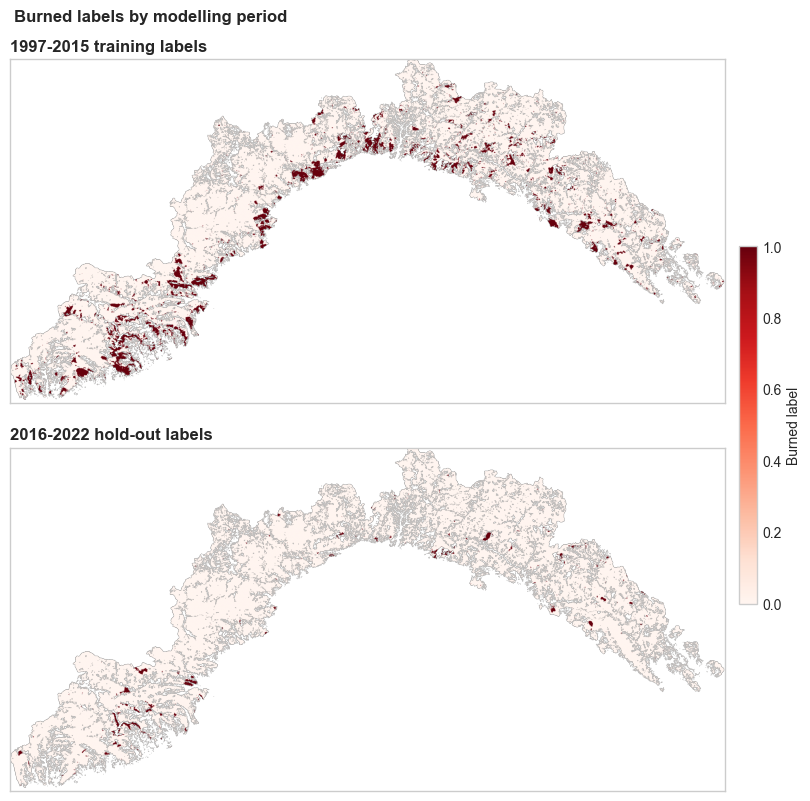

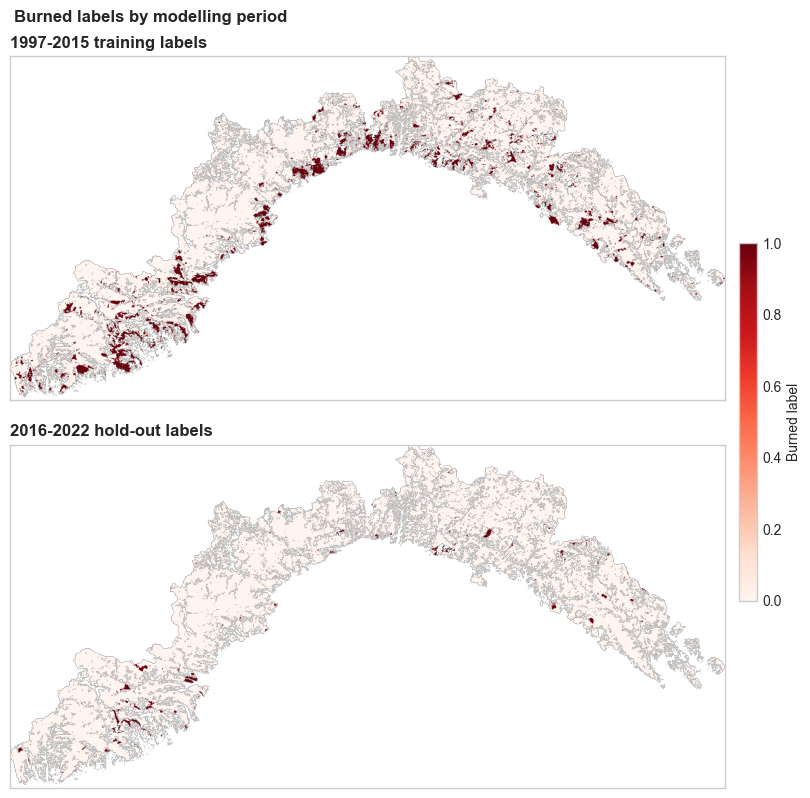

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), constrained_layout=True)

for ax, period_name, label_mask in [
    (axes[0], f"{min(train_years)}-{max(train_years)} training labels", train_burned_mask),
    (axes[1], f"{min(test_years)}-{max(test_years)} hold-out labels", test_burned_mask),
]:
    label_map = np.where(valid_mask, label_mask.astype(float), np.nan)
    image = ax.imshow(label_map, extent=extent, origin="upper", cmap="Reds", vmin=0, vmax=1)
    ax.set_title(period_name, loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02, label="Burned label")
fig.suptitle("Burned labels by modelling period", x=0.01, ha="left", fontweight="bold")
fig

In [12]:
# Training uses earlier fires; testing uses later fires. The training table
# keeps all pre-2016 burned pixels and samples an equal number of pre-2016
# pseudo-absence pixels from valid, unburned locations.
train_pool_df = sampled_period_table(
    train_burned_mask,
    f"{min(train_years)}-{max(train_years)}",
    RANDOM_STATE,
    valid_mask,
    TEMPLATE_TRANSFORM,
    raster_arrays,
    RASTER_FEATURES,
)
test_df = full_period_table(
    test_burned_mask,
    f"{min(test_years)}-{max(test_years)}",
    valid_mask,
    TEMPLATE_TRANSFORM,
    raster_arrays,
    RASTER_FEATURES,
)

train_pool_df = add_aspect_features(train_pool_df)
test_df = add_aspect_features(test_df)

# The validation split is internal to the balanced pre-2016 training pool.
# Stratification keeps the 50/50 presence/pseudo-absence ratio in both the
# model-fitting split and the validation split. The validation split is used for
# tuning, not for the final scientific evaluation.
train_model_df, validation_df = train_test_split(
    train_pool_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_pool_df["target"],
)

display(Markdown("### Training-pool sample"))
display(train_pool_df.head())

### Training-pool sample

,target,sample_type,row,col,x,y,elevation,slope,aspect,urban_distance,roads_distance,vegetation,period,target_name,aspect_eastness,aspect_northness
0,1,burned,37,1192,1.498304e+06,4.943334e+06,573.0,19.707232,189.035004,200.000000,141.421356,3113,1997-2015,burned,-0.157038,-0.987593
1,1,burned,37,1193,1.498404e+06,4.943334e+06,545.0,22.854176,128.739426,100.000000,100.000000,3112,1997-2015,burned,0.780000,-0.625780
2,1,burned,38,1192,1.498304e+06,4.943234e+06,533.0,23.478725,200.729736,223.606796,100.000000,3113,1997-2015,burned,-0.353960,-0.935260
3,1,burned,38,1193,1.498404e+06,4.943234e+06,522.0,25.305906,141.009003,141.421356,0.000000,3113,1997-2015,burned,0.629198,-0.777245
4,1,burned,38,1197,1.498804e+06,4.943234e+06,569.0,20.026087,206.916565,223.606796,0.000000,3113,1997-2015,burned,-0.452693,-0.891667


In [13]:
dataset_summary_df = pd.DataFrame(
    [
        {
            "dataset": "training pool",
            "period": train_pool_df["period"].iloc[0],
            "rows": len(train_pool_df),
            "burned_pixels": int(train_pool_df["target"].sum()),
            "sampled_unburned_pixels": int((train_pool_df["target"] == 0).sum()),
            "burned_share": float(train_pool_df["target"].mean()),
        },
        {
            "dataset": "model training split",
            "period": train_model_df["period"].iloc[0],
            "rows": len(train_model_df),
            "burned_pixels": int(train_model_df["target"].sum()),
            "sampled_unburned_pixels": int((train_model_df["target"] == 0).sum()),
            "burned_share": float(train_model_df["target"].mean()),
        },
        {
            "dataset": "validation split",
            "period": validation_df["period"].iloc[0],
            "rows": len(validation_df),
            "burned_pixels": int(validation_df["target"].sum()),
            "sampled_unburned_pixels": int((validation_df["target"] == 0).sum()),
            "burned_share": float(validation_df["target"].mean()),
        },
        {
            "dataset": "hold-out test",
            "period": test_df["period"].iloc[0],
            "rows": len(test_df),
            "burned_pixels": int(test_df["target"].sum()),
            "unburned_pixels": int((test_df["target"] == 0).sum()),
            "burned_share": float(test_df["target"].mean()),
        },
    ]
)
display(Markdown("### Dataset summary"))
display(dataset_summary_df)

### Dataset summary

,dataset,period,rows,burned_pixels,sampled_unburned_pixels,burned_share,unburned_pixels
0,training pool,1997-2015,71824,35912,35912.0,0.500000,NaN
1,model training split,1997-2015,57459,28730,28729.0,0.500009,NaN
2,validation split,1997-2015,14365,7182,7183.0,0.499965,NaN
3,hold-out test,2016-2022,398697,5806,NaN,0.014562,392891.0


In [14]:
sample_summary_df = (
    pd.concat([train_pool_df, test_df], ignore_index=True)
    .groupby(["period", "target_name"], observed=True)
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
display(Markdown("### Pixel samples by period"))
display(sample_summary_df)

### Pixel samples by period

,period,burned,unburned
0,1997-2015,35912,35912
1,2016-2022,5806,392891


## Quick exploratory analysis

Before fitting a model, ask whether burned and unburned sampled pixels differ
in the pre-2016 training pool.

In [15]:
class_summary_df = (
    train_pool_df.groupby("target_name", observed=True)[NUMERIC_FEATURES]
    .median()
    .T.rename_axis("feature")
    .reset_index()
)
display(Markdown("### Class-wise median numeric predictors"))
display(class_summary_df)

### Class-wise median numeric predictors

target_name,feature,burned,unburned
0,elevation,467.000000,560.000000
1,slope,21.339418,18.894865
2,aspect_eastness,0.158466,0.018493
3,aspect_northness,-0.563900,0.006849
4,urban_distance,583.095154,583.095154
5,roads_distance,316.227783,300.000000


In [16]:
vegetation_summary_df = (
    pd.crosstab(
        train_pool_df["vegetation"].map(VEGETATION_NAMES).fillna(train_pool_df["vegetation"].astype(str)),
        train_pool_df["target_name"],
        normalize="columns",
    )
    .mul(100)
    .sort_values("burned", ascending=False)
    .head(8)
)
display(Markdown("### Top vegetation classes by sampled burned share"))
display(vegetation_summary_df)

### Top vegetation classes by sampled burned share

target_name,burned,unburned
vegetation,,
Warm-climate mixed forest,20.976275,16.576632
Mediterranean evergreen scrub,18.684562,1.793272
Shrubland and scrub,13.313099,2.748385
Mixed forest,11.266429,13.803186
Chestnut forest,10.740143,26.356093
Coniferous forest,10.135888,8.075295
Woodland-shrub transition,6.251392,5.658276
Moist-climate mixed forest,4.497104,12.190911


### Compare all predictors by sampled class

These plots use the balanced pre-2016 training pool. Blue is the sampled
pseudo-absence class; red is the burned class.

Numeric predictors are shown as density histograms. Vegetation is categorical,
so it is shown as class percentages within burned and unburned samples.
Strong separation suggests a feature may help rank susceptibility, while heavy
overlap means the model will need combinations of variables rather than a
single threshold.

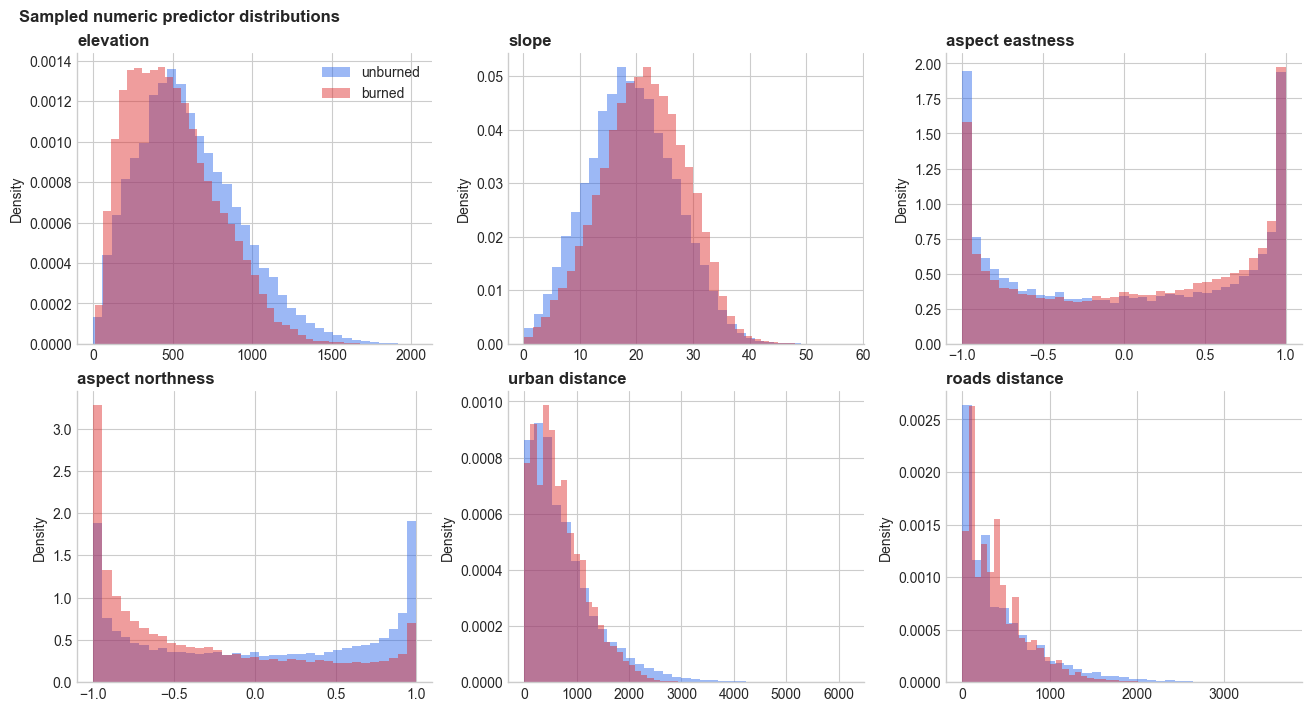

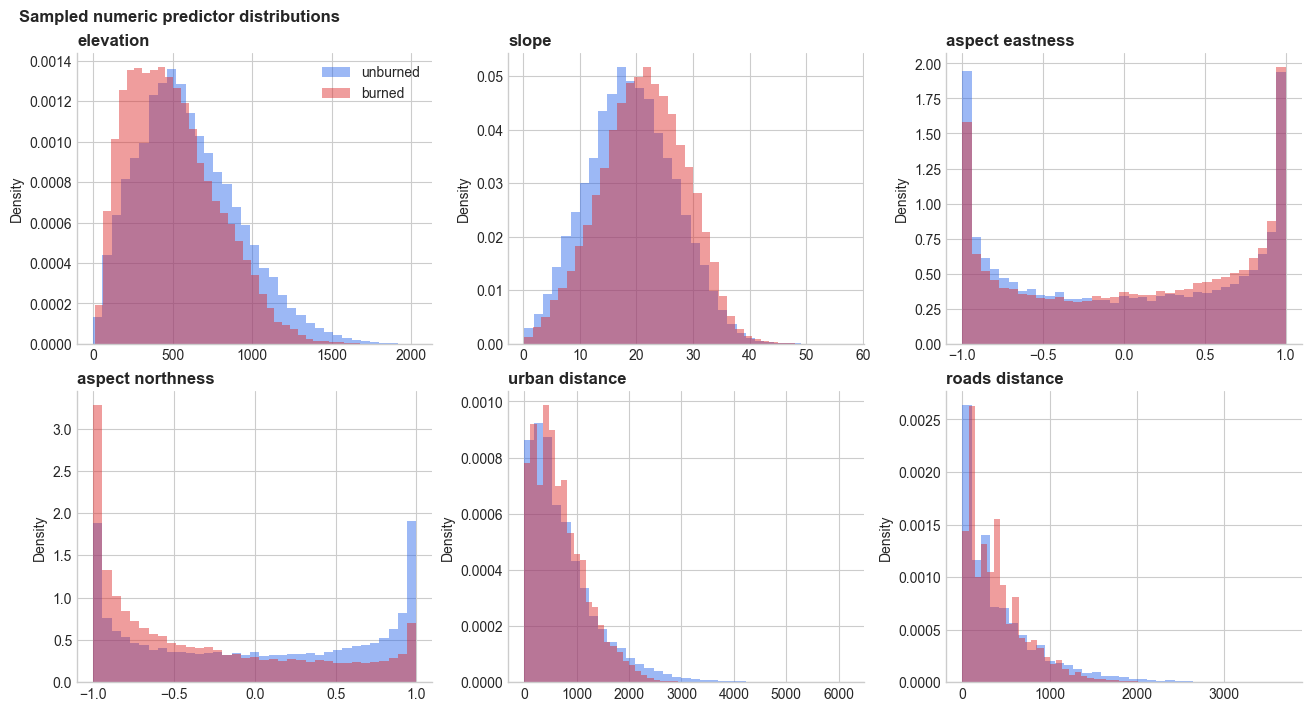

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
axes = axes.ravel()

for ax, feature in zip(axes, NUMERIC_FEATURES):
    for target, label, color in [(0, "unburned", "#2563eb"), (1, "burned", "#dc2626")]:
        ax.hist(
            train_pool_df.loc[train_pool_df["target"] == target, feature],
            bins=35,
            density=True,
            alpha=0.45,
            color=color,
            label=label,
        )
    ax.set_title(feature.replace("_", " "), loc="left", fontweight="bold")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle("Sampled numeric predictor distributions", x=0.01, ha="left", fontweight="bold")
fig

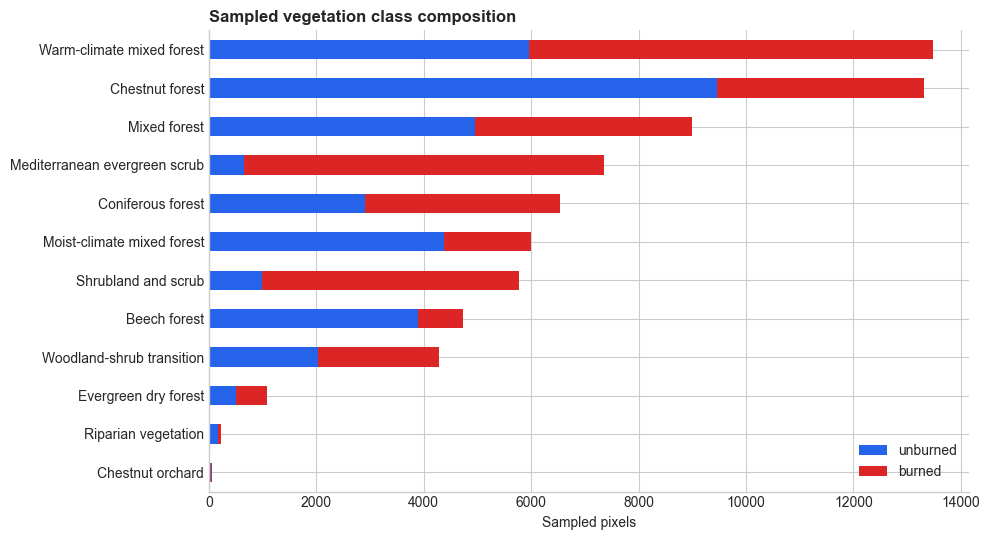

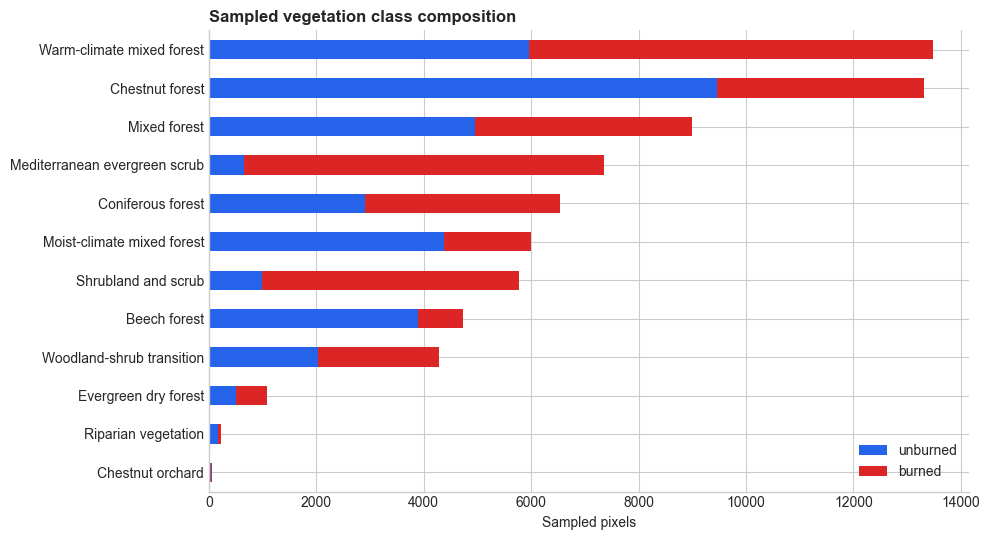

In [18]:
vegetation_plot_df = (
    pd.crosstab(
        train_pool_df["vegetation"].map(VEGETATION_NAMES).fillna(train_pool_df["vegetation"].astype(str)),
        train_pool_df["target_name"],
    )
    .reindex(columns=["unburned", "burned"], fill_value=0)
    .assign(total=lambda frame: frame.sum(axis=1))
    .sort_values("total", ascending=True)
)
vegetation_count_plot_df = vegetation_plot_df[["unburned", "burned"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
vegetation_count_plot_df.plot.barh(stacked=True, ax=ax, color=["#2563eb", "#dc2626"])
ax.set_title("Sampled vegetation class composition", loc="left", fontweight="bold")
ax.set_xlabel("Sampled pixels")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="", frameon=False)
fig.tight_layout()
fig

In [19]:
numeric_contrast_df = (
    train_pool_df.groupby("target_name", observed=True)[NUMERIC_FEATURES]
    .median()
    .T.rename(columns={"burned": "burned_median", "unburned": "unburned_median"})
)
numeric_contrast_df["burned_minus_unburned"] = (
    numeric_contrast_df["burned_median"] - numeric_contrast_df["unburned_median"]
)
numeric_contrast_df = numeric_contrast_df.reset_index(names="feature")

vegetation_contrast_df = vegetation_count_plot_df.reset_index(names="vegetation_class")
vegetation_contrast_df["burned_minus_unburned_pixels"] = (
    vegetation_contrast_df["burned"] - vegetation_contrast_df["unburned"]
)

display(Markdown("### Numeric predictor median contrasts"))
display(numeric_contrast_df)
display(Markdown("### Vegetation class count contrasts"))
display(vegetation_contrast_df)

### Numeric predictor median contrasts

target_name,feature,burned_median,unburned_median,burned_minus_unburned
0,elevation,467.000000,560.000000,-93.000000
1,slope,21.339418,18.894865,2.444553
2,aspect_eastness,0.158466,0.018493,0.139973
3,aspect_northness,-0.563900,0.006849,-0.570749
4,urban_distance,583.095154,583.095154,0.000000
5,roads_distance,316.227783,300.000000,16.227783


### Vegetation class count contrasts

target_name,vegetation_class,unburned,burned,burned_minus_unburned_pixels
0,Chestnut orchard,34,17,-17
1,Riparian vegetation,165,55,-110
2,Evergreen dry forest,496,590,94
3,Woodland-shrub transition,2032,2245,213
4,Beech forest,3901,823,-3078
5,Shrubland and scrub,987,4781,3794
6,Moist-climate mixed forest,4378,1615,-2763
7,Coniferous forest,2900,3640,740
8,Mediterranean evergreen scrub,644,6710,6066
9,Mixed forest,4957,4046,-911


In the bundled data, pre-2016 burned samples are typically lower, steeper, and
more south-facing than the sampled unburned comparison pixels. The largest
vegetation contrasts are also plausible for a Ligurian wildfire example:
Mediterranean evergreen scrub and shrubland are over-represented among burned
samples, while chestnut and moist-climate mixed forest are under-represented.

These summaries are descriptive, not causal. They are computed from the same
balanced sampling design used for fitting, so they describe the modelling
contrast rather than the true landscape prevalence of each class.

### Apply feature engineering to the prepared datasets

The feature-engineering helpers were defined before the sampling section. Now
that the training, validation, and hold-out tables exist, we can convert them
into model matrices.

In [20]:
# Fit the encoding vocabulary on the model-training split.
X_train = make_features(train_model_df)
FEATURE_COLUMNS = X_train.columns

# Reuse the same columns everywhere.
X_valid = make_features(validation_df, FEATURE_COLUMNS)
X_test = make_features(test_df, FEATURE_COLUMNS)

y_train = train_model_df["target"]
y_valid = validation_df["target"]
y_test = test_df["target"]

display(Markdown("### Encoded feature columns"))
display(list(FEATURE_COLUMNS))

### Encoded feature columns

['elevation',
 'slope',
 'aspect_eastness',
 'aspect_northness',
 'urban_distance',
 'roads_distance',
 'vegetation_312',
 'vegetation_313',
 'vegetation_322',
 'vegetation_323',
 'vegetation_324',
 'vegetation_3111',
 'vegetation_3112',
 'vegetation_3113',
 'vegetation_3114',
 'vegetation_3115',
 'vegetation_3116',
 'vegetation_3117']

## 5. Model tuning

Tuning chooses hyperparameters using only the pre-2016 training and validation
data. The 2016-2022 hold-out test set is still untouched.

`PredefinedSplit` tells `GridSearchCV` exactly which rows are training rows
and which rows are validation rows:

- `-1` means "use this row for fitting"
- `0` means "use this row for validation"

In [21]:
param_grid = {
    "n_estimators": [150, 300],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 3, 5],
    "max_depth": [None, 15],
}

X_tuning = pd.concat([X_train, X_valid], ignore_index=True)
y_tuning = pd.concat([y_train, y_valid], ignore_index=True)

fold_labels = []
for _ in range(len(X_train)):
    fold_labels.append(-1)
for _ in range(len(X_valid)):
    fold_labels.append(0)

validation_fold = PredefinedSplit(test_fold=fold_labels)

tuning_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring=["roc_auc"],
    refit="roc_auc",
    cv=validation_fold,
    n_jobs=1,
)
tuning_search.fit(X_tuning, y_tuning)

tuning_results_df = (
    pd.DataFrame(tuning_search.cv_results_)
    .sort_values("rank_test_roc_auc")
    [
        [
            "rank_test_roc_auc",
            "mean_test_roc_auc",
            "param_n_estimators",
            "param_max_features",
            "param_min_samples_leaf",
            "param_max_depth",
        ]
    ]
    .reset_index(drop=True)
)
display(Markdown("### Top tuning results"))
display(tuning_results_df.head(10))

### Top tuning results

,rank_test_roc_auc,mean_test_roc_auc,param_n_estimators,param_max_features,param_min_samples_leaf,param_max_depth
0,1,0.837735,300,sqrt,1,None
1,2,0.837171,300,0.5,3,None
2,3,0.837133,300,sqrt,3,None
3,4,0.836736,300,0.5,1,None
4,5,0.836656,150,sqrt,1,None
5,6,0.836238,150,sqrt,3,None
6,7,0.836044,150,0.5,3,None
7,8,0.835745,300,0.5,5,None
8,9,0.835664,150,0.5,1,None
9,10,0.835334,300,sqrt,5,None


In [22]:
best_params = tuning_search.best_params_
display(Markdown("### Selected hyperparameters"))
display(best_params)

### Selected hyperparameters

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'n_estimators': 300}

## 6. Training

After tuning, we fit two models with the selected hyperparameters:

- `validation_model` is fitted only on the model-training split, so validation
  metrics are honest diagnostics.
- `rf_model` is fitted on the full balanced pre-2016 training pool, so it uses
  all pre-2016 samples before the final hold-out test.

`GridSearchCV` also refits a model internally, but that refit has already seen
validation rows. We do not use it for validation reporting.

In [23]:
validation_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
validation_model.fit(X_train, y_train)

X_train_pool = make_features(train_pool_df, FEATURE_COLUMNS)
y_train_pool = train_pool_df["target"]

rf_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_pool, y_train_pool)

display(Markdown("### Fitted Random Forest"))
display(rf_model)

### Fitted Random Forest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 7. Testing

Susceptibility is usually used as a ranking.
The key hold-out evaluation question is:

**Do 2016-2022 burned pixels receive higher scores than all valid 2016-2022
unburned pixels?**

The validation split and the hold-out set should not be read as the same kind
of test. Validation is a balanced sample from the pre-2016 training period,
used to choose hyperparameters. The hold-out set is the full valid landscape
in 2016-2022, so it keeps the real rare-event class imbalance.

This section only creates scores. The next section turns those scores into
metrics.

In [24]:
def fire_score(model, X):
    # predict_proba returns one column per class; select the probability of class 1.
    return model.predict_proba(X)[:, list(model.classes_).index(1)]


validation_scores = validation_df[["target", "target_name", "row", "col", "x", "y"]].copy()
validation_scores["score"] = fire_score(validation_model, X_valid)

test_scores = test_df[["target", "target_name", "row", "col", "x", "y"]].copy()
test_scores["score"] = fire_score(rf_model, X_test)

score_summary_df = pd.DataFrame(
    [
        {
            "dataset": "validation",
            "rows": len(validation_scores),
            "burned_share": validation_scores["target"].mean(),
            "mean_score": validation_scores["score"].mean(),
        },
        {
            "dataset": "hold-out test",
            "rows": len(test_scores),
            "burned_share": test_scores["target"].mean(),
            "mean_score": test_scores["score"].mean(),
        },
    ]
)
display(Markdown("### Score summary"))
display(score_summary_df)

### Score summary

,dataset,rows,burned_share,mean_score
0,validation,14365,0.499965,0.506007
1,hold-out test,398697,0.014562,0.361670


## 8. Metrics

Validation and hold-out metrics are reported in separate tables because they
describe different evaluation populations. The validation set is a balanced
sample, while the hold-out set is the full valid landscape.

In [25]:
TOP_RECALL_SHARES = [0.10, 0.25, 0.50]


def recall_at_top_percent(y_true, score, top_share):
    """Share of burned pixels captured inside the highest-scoring map fraction."""
    y_true = np.asarray(y_true)
    score = np.asarray(score)

    if not 0 < top_share <= 1:
        raise ValueError("top_share must be in the interval (0, 1].")

    # Top-percentile recall answers the operational question directly:
    # if only this share of the territory can be prioritized, how many observed
    # fires would it have included? Ties at the cutoff can make the mapped share
    # slightly larger than the requested share, which is preferable to silently
    # dropping equally scored pixels.
    threshold = np.quantile(score, 1 - top_share)
    return recall_score(y_true, score >= threshold, zero_division=0)


def boyce_index(y_true, score, n_bins=10):
    """Continuous Boyce Index from presence/background score bins.

    Positive values mean observed burned pixels are concentrated in higher
    score bins. Values near zero mean the ranking is close to random, and
    negative values mean burned pixels are concentrated in lower score bins.
    """
    y_true = np.asarray(y_true)
    score = np.asarray(score)

    presence_score = score[y_true == 1]
    if presence_score.size == 0 or np.unique(score).size < 2:
        return np.nan

    # Quantile bins keep background counts reasonably even across skewed Random
    # Forest scores. Duplicate edges are dropped because tree ensembles often
    # assign identical probabilities to many pixels.
    bin_edges = np.unique(np.quantile(score, np.linspace(0, 1, n_bins + 1)))
    if bin_edges.size < 3:
        return np.nan

    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    background_counts, _ = np.histogram(score, bins=bin_edges)
    presence_counts, _ = np.histogram(presence_score, bins=bin_edges)
    valid_bins = (background_counts > 0) & (presence_counts > 0)
    if valid_bins.sum() < 2:
        return np.nan

    expected = background_counts[valid_bins] / background_counts.sum()
    observed = presence_counts[valid_bins] / presence_counts.sum()
    predicted_expected_ratio = observed / expected

    # Boyce is the Spearman correlation between bin suitability and the
    # presence-to-expected ratio, so it only trusts monotonic ordering, not
    # absolute probability calibration.
    bin_id = np.digitize(score, bin_edges[1:-1], right=True)
    mean_score_by_bin = np.array(
        [score[bin_id == i].mean() for i in range(len(bin_edges) - 1)]
    )[valid_bins]
    return pd.Series(mean_score_by_bin).corr(pd.Series(predicted_expected_ratio), method="spearman")


def validation_score_metrics(name, y, score):
    return {
        "model": name,
        "evaluation_population": "balanced pre-2016 validation sample",
        "rows": len(y),
        "burned_share": float(np.mean(y)),
        "ROC-AUC": roc_auc_score(y, score),
    }


def holdout_landscape_metrics(name, y, score):
    metrics = {
        "model": name,
        "evaluation_population": "full 2016-2022 valid landscape",
        "rows": len(y),
        "burned_share": float(np.mean(y)),
        "ROC-AUC": roc_auc_score(y, score),
        "Boyce Index": boyce_index(y, score),
    }

    for top_share in TOP_RECALL_SHARES:
        metric_name = f"Recall@Top {int(top_share * 100)}%"
        metrics[metric_name] = recall_at_top_percent(y, score, top_share)

    return metrics


validation_metrics_df = pd.DataFrame(
    [validation_score_metrics("tuned random forest", y_valid, validation_scores["score"])]
).set_index("model")
display(Markdown("### Balanced validation tuning diagnostics"))
display(validation_metrics_df)

### Balanced validation tuning diagnostics

,evaluation_population,rows,burned_share,ROC-AUC
model,,,,
tuned random forest,balanced pre-2016 validation sample,14365,0.499965,0.837735


In [26]:
holdout_metrics_df = pd.DataFrame(
    [holdout_landscape_metrics("tuned random forest", y_test, test_scores["score"])]
).set_index("model")
display(Markdown("### Full-landscape hold-out metrics"))
display(holdout_metrics_df)

### Full-landscape hold-out metrics

,evaluation_population,rows,burned_share,ROC-AUC,Boyce Index,Recall@Top 10%,Recall@Top 25%,Recall@Top 50%
model,,,,,,,,
tuned random forest,full 2016-2022 valid landscape,398697,0.014562,0.794049,1.0,0.497416,0.696176,0.857217


The validation table answers a narrow modelling question: after tuning, does
the selected Random Forest rank burned pixels above sampled pseudo-absences in
the balanced pre-2016 validation split? It is useful for model selection, but
it is not an estimate of landscape performance.

The hold-out table answers the application question on the full 2016-2022
landscape. On the bundled data the hold-out ROC-AUC is about 0.80, meaning
later burned pixels usually rank above later unburned pixels.

Recall@Top% is the most directly operational metric here. In the hold-out
period, the top 10% of scored territory captures about half of the observed
burned pixels, and the top 25% captures about 70%. This is a useful ranking
signal, but it is not a calibrated annual probability.

The Boyce Index is a monotonic bin diagnostic, so it can saturate when each
successive score bin has a higher burned-pixel concentration. Treat it as
supporting evidence for the ranking, not as a replacement for ROC-AUC or the
top-percentile recall values.

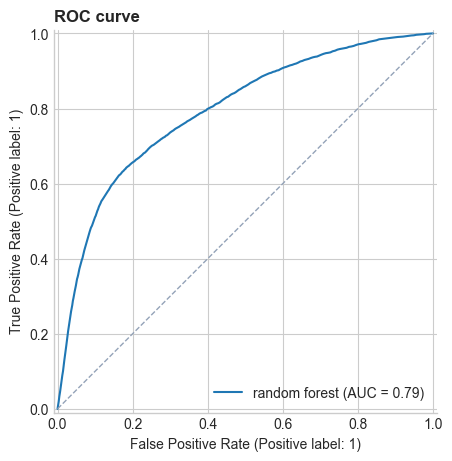

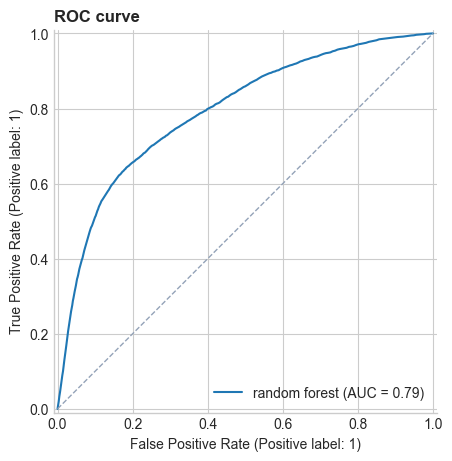

In [27]:
fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)

RocCurveDisplay.from_estimator(rf_model, X_test, y_test, name="random forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="#94a3b8", linewidth=1)
ax.set_title("ROC curve", loc="left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig

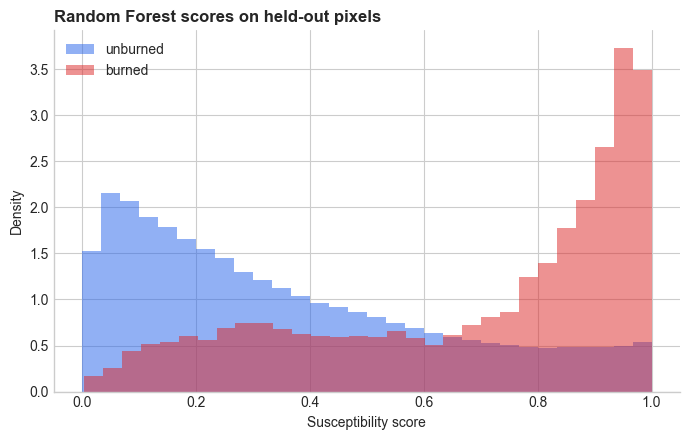

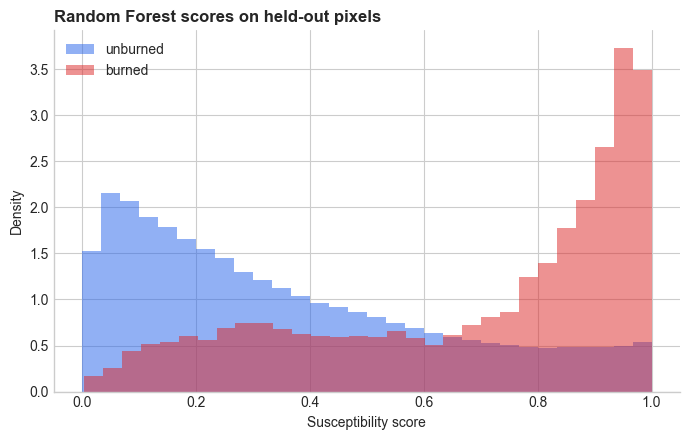

In [28]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for target, label, color in [(0, "unburned", "#2563eb"), (1, "burned", "#dc2626")]:
    ax.hist(test_scores.loc[test_scores["target"] == target, "score"], bins=30, density=True, alpha=0.5, color=color, label=label)
ax.set_title("Random Forest scores on held-out pixels", loc="left", fontweight="bold")
ax.set_xlabel("Susceptibility score")
ax.set_ylabel("Density")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
fig

In [29]:
score_bin = pd.qcut(test_scores["score"], q=10, duplicates="drop")
score_bin_df = (
    test_scores.assign(score_bin=score_bin)
    .groupby("score_bin", observed=True)
    .agg(
        rows=("target", "size"),
        mean_score=("score", "mean"),
        observed_presence_share=("target", "mean"),
    )
    .reset_index()
)
score_bin_df["lift_vs_landscape"] = score_bin_df["observed_presence_share"] / test_scores["target"].mean()
display(Markdown("### Observed burned share by score bin"))
display(score_bin_df)

### Observed burned share by score bin

,score_bin,rows,mean_score,observed_presence_share,lift_vs_landscape
0,"(-0.001, 0.0567]",42600,0.032451,0.001526,0.104778
1,"(0.0567, 0.103]",37888,0.081284,0.002982,0.204806
2,"(0.103, 0.16]",41114,0.132831,0.004354,0.298971
3,"(0.16, 0.22]",38516,0.191079,0.005063,0.347664
4,"(0.22, 0.293]",40596,0.257133,0.007217,0.495622
5,"(0.293, 0.38]",39514,0.337006,0.008984,0.616941
6,"(0.38, 0.487]",39751,0.433432,0.009459,0.649540
7,"(0.487, 0.62]",39009,0.551576,0.011587,0.795682
8,"(0.62, 0.807]",40179,0.711163,0.022873,1.570661
9,"(0.807, 1.0]",39530,0.906637,0.072325,4.966532


The score bins show why the model should be read as a ranking. The observed
burned share rises from well below the landscape base rate in the lowest score
bin to several times the base rate in the highest score bin. The top bin is
still mostly unburned pixels, because fire is rare even in susceptible areas.

## Thresholds are decisions

The Random Forest gives a score. Any threshold turns that score into a class
label, but there is no universal wildfire threshold. The choice depends on the
cost of missing susceptible areas versus over-flagging lower-susceptibility
areas.

Percentile thresholds are a practical way to avoid pretending that one raw
score cutoff, such as 0.5, has a universal meaning. Instead of saying "score
above 0.5 is high risk", define high susceptibility as a territory share: for
example, the top 10%, 25%, or 50% of valid pixels by model score.

This is often easier to explain to stakeholders than a raw model probability:
for example, "high susceptibility" can mean the top 25% of valid pixels by
Random Forest score.

The percentile is a policy choice. A smaller high-susceptibility area is easier
to inspect or prioritize, but it will miss more burned pixels. The hold-out test
below quantifies this trade-off using 2016-2022 fires.

In [30]:
baseline_burned_share = test_scores["target"].mean()

operational_threshold_rows = []
for high_risk_share in [0.10, 0.25, 0.50]:
    score_threshold = test_scores["score"].quantile(1 - high_risk_share)
    selected = test_scores["score"] >= score_threshold
    operational_threshold_rows.append(
        {
            "high_risk_territory_share": high_risk_share,
            "score_percentile_threshold": 1 - high_risk_share,
            "score_threshold": score_threshold,
            "mapped_high_risk_share": float(selected.mean()),
            "captured_burned_share": recall_score(y_test, selected, zero_division=0),
        }
    )

operational_threshold_df = pd.DataFrame(operational_threshold_rows)
display(Markdown("### Operational percentile thresholds on hold-out period"))
display(operational_threshold_df)

### Operational percentile thresholds on hold-out period

,high_risk_territory_share,score_percentile_threshold,score_threshold,mapped_high_risk_share,captured_burned_share
0,0.10,0.90,0.806667,0.100831,0.497416
1,0.25,0.75,0.546667,0.252387,0.696176
2,0.50,0.50,0.293333,0.500706,0.857217


The threshold table expresses the same ranking in decision terms. Selecting
the top 10% of valid pixels maps less territory, but misses nearly half of the
hold-out burned pixels. Selecting the top 50% captures most burned pixels but
includes much more territory. The right threshold therefore depends on the
operational cost of field checks, fuel management, or missed susceptible areas.

In [31]:
medium_threshold = test_scores["score"].quantile(0.50)
high_threshold = test_scores["score"].quantile(0.75)

test_scores["susceptibility_class"] = pd.cut(
    test_scores["score"],
    bins=[-np.inf, medium_threshold, high_threshold, np.inf],
    labels=["low", "medium", "high"],
    include_lowest=True,
)

susceptibility_class_df = (
    test_scores.groupby("susceptibility_class", observed=True)
    .agg(
        pixels=("target", "size"),
        territory_share=("target", lambda values: len(values) / len(test_scores)),
        mean_score=("score", "mean"),
        burned_pixels=("target", "sum"),
        observed_burned_share=("target", "mean"),
    )
    .reset_index()
)
susceptibility_class_df["captured_burned_share"] = susceptibility_class_df["burned_pixels"] / test_scores["target"].sum()
susceptibility_class_df["lift_vs_landscape"] = susceptibility_class_df["observed_burned_share"] / baseline_burned_share
display(Markdown("### Low, medium, high susceptibility classes on hold-out period"))
display(susceptibility_class_df)

### Low, medium, high susceptibility classes on hold-out period

,susceptibility_class,pixels,territory_share,mean_score,burned_pixels,observed_burned_share,captured_burned_share,lift_vs_landscape
0,low,200714,0.503425,0.138115,845,0.004210,0.145539,0.289098
1,medium,98371,0.246731,0.411095,934,0.009495,0.160868,0.651997
2,high,99612,0.249844,0.763317,4027,0.040427,0.693593,2.776105


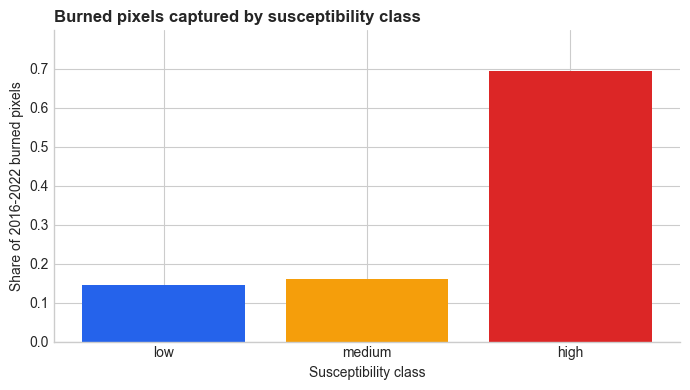

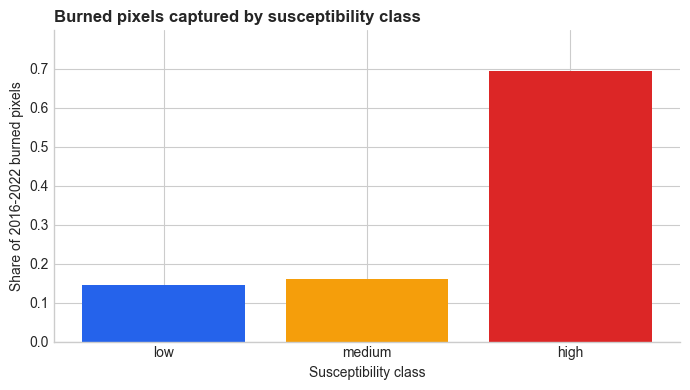

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
class_plot_df = susceptibility_class_df.set_index("susceptibility_class").loc[["low", "medium", "high"]]
ax.bar(class_plot_df.index, class_plot_df["captured_burned_share"], color=["#2563eb", "#f59e0b", "#dc2626"])
ax.set_title("Burned pixels captured by susceptibility class", loc="left", fontweight="bold")
ax.set_xlabel("Susceptibility class")
ax.set_ylabel("Share of 2016-2022 burned pixels")
ax.set_ylim(0, max(0.05, class_plot_df["captured_burned_share"].max() * 1.15))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig

Fixed raw score thresholds are shown only as a sensitivity check. They are
less portable than percentile thresholds because the numeric score scale
depends on the model, sampling design, and predictor set.

In [33]:
threshold_df = pd.DataFrame(
    [
        {
            "threshold": threshold,
            "mapped_positive_share": float((test_scores["score"] >= threshold).mean()),
            "captured_burned_share": recall_score(y_test, test_scores["score"] >= threshold, zero_division=0),
        }
        for threshold in [0.25, 0.50, 0.75]
    ]
)
display(Markdown("### Threshold sensitivity"))
display(threshold_df)

### Threshold sensitivity

,threshold,mapped_positive_share,captured_burned_share
0,0.25,0.558866,0.889597
1,0.50,0.289538,0.723045
2,0.75,0.129113,0.562177


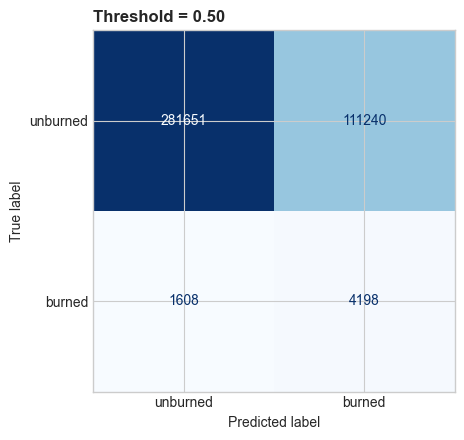

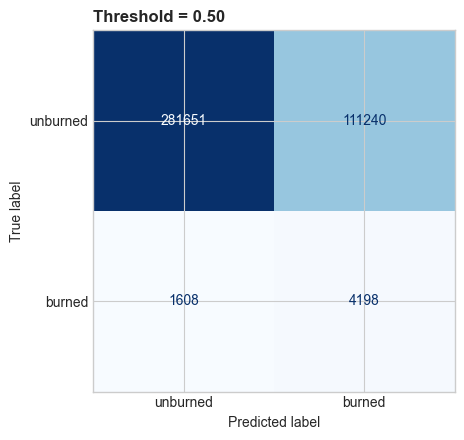

In [34]:
threshold = 0.50

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_scores["score"] >= threshold,
    display_labels=["unburned", "burned"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"Threshold = {threshold:.2f}", loc="left", fontweight="bold")
fig.tight_layout()
fig

## Validation design matters

The validation split is random within the pre-2016 training pool, so it is
useful for tuning but still optimistic for spatial data.

The 2016-2022 hold-out is a harder test because it evaluates later fires that
were not used for fitting or tuning. It is still not perfect: nearby pixels can
share terrain, vegetation, accessibility, and fire history.

## 9. Model explanation

MDA means Mean Decrease in Accuracy.
Here "accuracy" is the ranking metric we care about: hold-out ROC AUC.

The idea is simple: shuffle one original predictor, score the model again,
and measure how much ROC AUC decreases.

We ask scikit-learn to permute the original pre-encoded columns. For
`vegetation`, this means the single vegetation code column is shuffled as one
variable.

This is model interpretation, not causal attribution.
For example, vegetation class can proxy fuel structure, land management, and
geography; permutation importance cannot separate those mechanisms by itself.

In [35]:
def raw_feature_auc(model, raw_X, y):
    # permutation_importance passes the raw pre-encoded frame here.
    # Encode it with the same columns used to train the model, then score it.
    encoded_X = make_features(raw_X, FEATURE_COLUMNS)
    return roc_auc_score(y, fire_score(model, encoded_X))


importance = permutation_importance(
    rf_model,
    test_df[FEATURES],
    y_test,
    scoring=raw_feature_auc,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": FEATURES,
            "mda_roc_auc_drop": importance.importances_mean,
            "std": importance.importances_std,
        }
    )
    .sort_values("mda_roc_auc_drop", ascending=False)
    .reset_index(drop=True)
)
display(Markdown("### Permutation importance on hold-out period"))
display(importance_df)

### Permutation importance on hold-out period

,feature,mda_roc_auc_drop,std
0,vegetation,0.172830,0.002152
1,aspect_northness,0.050653,0.001319
2,elevation,0.042411,0.000608
3,slope,0.038043,0.001394
4,urban_distance,0.030546,0.000867
5,roads_distance,0.027763,0.001835
6,aspect_eastness,0.011843,0.000827


Vegetation is the dominant predictor in this fitted baseline, followed by
northness, elevation, slope, and accessibility distances. This is consistent
with the exploratory contrasts: vegetation class and south-facing exposure
separate the sampled burned pixels from the sampled pseudo-absences.

The interpretation remains associational. A large MDA drop means the trained
Random Forest relied on that variable for hold-out ranking. It does not prove
that changing the variable would change fire occurrence.

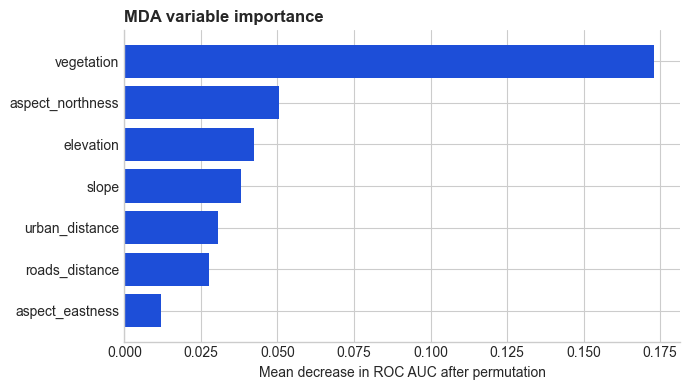

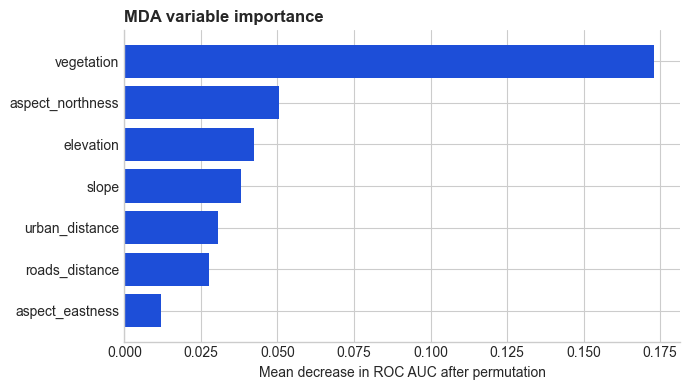

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = importance_df.sort_values("mda_roc_auc_drop")
ax.barh(plot_df["feature"], plot_df["mda_roc_auc_drop"], color="#1d4ed8")
ax.set_title("MDA variable importance", loc="left", fontweight="bold")
ax.set_xlabel("Mean decrease in ROC AUC after permutation")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig

## Susceptibility map

For a strict hold-out evaluation, the mapped model below is still fitted only
on the pre-2016 training pool with the selected hyperparameters.

The map is a model product. It is not independent evidence of accuracy.

### Mapped susceptibility score summary

count    398697.000000
mean          0.361670
std           0.274364
min           0.000000
10%           0.056667
50%           0.293333
90%           0.806667
max           1.000000
dtype: float64

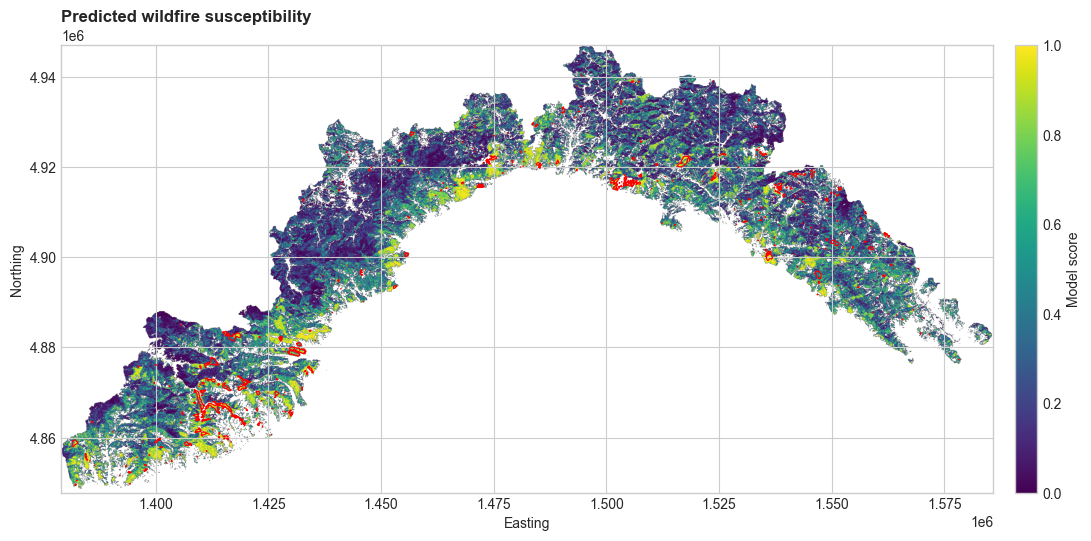

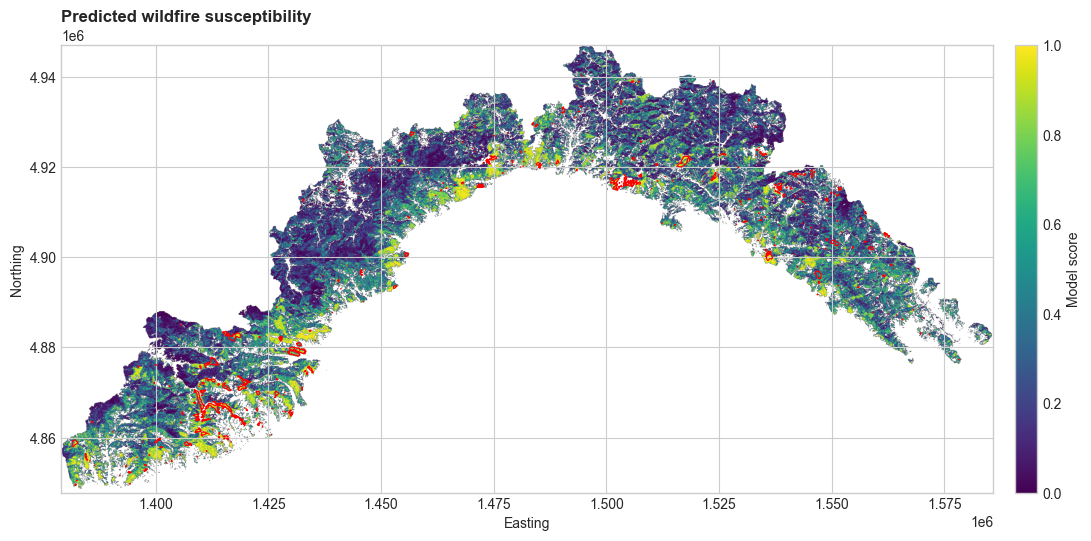

In [37]:
final_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_model.fit(X_train_pool, y_train_pool)

rows, cols = np.where(valid_mask)
grid_pixels = pixel_frame(
    rows,
    cols,
    target=0,
    sample_type="map",
    template_transform=TEMPLATE_TRANSFORM,
    raster_arrays=raster_arrays,
    features=RASTER_FEATURES,
)

# Predict the fitted model over every valid pixel to create the susceptibility map.
grid_features = make_features(grid_pixels, FEATURE_COLUMNS)
grid_scores = fire_score(final_model, grid_features)

susceptibility_grid = np.full(TEMPLATE_SHAPE, np.nan, dtype=float)
susceptibility_grid[rows, cols] = grid_scores

grid_score_summary = pd.Series(grid_scores).describe(percentiles=[0.1, 0.5, 0.9])
display(Markdown("### Mapped susceptibility score summary"))
display(grid_score_summary)

fig, ax = plt.subplots(figsize=(12, 5.5))
image = ax.imshow(susceptibility_grid, extent=extent, origin="upper", cmap="viridis", vmin=0, vmax=1)

# Red contours show the true burned pixels from the 2016-2022 hold-out period.
# This overlay is visual evaluation only; the numeric test metrics above are the formal evaluation.
holdout_burned_mask = test_burned_mask & valid_mask
ax.contour(
    holdout_burned_mask.astype(int),
    levels=[0.5],
    extent=extent,
    origin="upper",
    colors="red",
    linewidths=0.8,
)

ax.set_title("Predicted wildfire susceptibility", loc="left", fontweight="bold")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal", adjustable="box")
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02, label="Model score")
fig.tight_layout()
fig

## Take-home messages

- Raster predictors can be converted into a tabular supervised-learning problem.
- Yearly burned-area rasters provide positives; sampled unburned pixels define the comparison group.
- Elevation, slope, aspect, vegetation, and accessibility distances are used as static predictors.
- Categorical raster classes can be made numeric with simple dummy variables.
- Use the validation split only for model selection; report validation metrics with a model that has not been refit on validation rows.
- Keep the 2016-2022 hold-out years untouched until final evaluation.
- On the bundled data, the hold-out ROC-AUC is about 0.80 and the top quarter of the map captures about 70% of later burned pixels.
- Percentile thresholds translate model scores into operational territory shares, but the threshold is a decision rule, not a property of the model.
- MDA variable importance explains model behavior, not ecological causality.
- The susceptibility map is a model output and must be interpreted with the sampling and validation design in mind.

## Exercises

1. **Add temperature and rain predictors.**
   Extend `RASTER_PATHS`, `RASTER_NUMERIC_FEATURES`, `NUMERIC_FEATURES`,
   `RASTER_FEATURES`, and `FEATURES` with the climate rasters in `data/`:

   - `temperature_summer.tif`
   - `temperature_winter.tif`
   - `precipitation_summer.tif`
   - `precipitation_winter.tif`

   Re-run the workflow and compare the baseline Random Forest with the
   climate-augmented Random Forest. Report at least ROC AUC, Boyce Index,
   and top-percentile recall on the 2016-2022 hold-out period. Also inspect whether the
   climate variables appear important in the MDA table.

2. **Try another learning algorithm.**
   Replace or complement `RandomForestClassifier` with another classifier,
   such as `HistGradientBoostingClassifier`, `ExtraTreesClassifier`,
   `LogisticRegression`, or `KNeighborsClassifier`. Keep the same train,
   validation, and 2016-2022 hold-out splits so the comparison is fair.
   Compare validation metrics, hold-out metrics, and the shape of the score
   distributions.

3. **Use a geographical split.**
   Design a spatial validation strategy instead of the temporal hold-out. For
   example, split pixels by easting or northing, train on one part of Liguria,
   and test on the held-out part. Compare the result with the temporal split.
   Does the model still generalize when evaluated on places it did not see
   during fitting? Explain how the geographical split changes the scientific
   question being tested.